# Chapter 10: Direct Preference Optimization (DPO)

## Complete DPO Training Pipeline

This notebook implements Direct Preference Optimization for aligning language models with human preferences.

**What you'll do:**
1. Download preference datasets (Anthropic HH-RLHF)
2. Prepare and format data for DPO
3. Implement DPO loss function
4. Train model with preference optimization
5. Evaluate alignment (safety, helpfulness, honesty)
6. Compare before/after DPO

**Prerequisites:**
- Chapter 9 SFT model (or use simple model for demo)
- GPU recommended (T4 or better)
- ~2-4 hours training time

**Author:** Chapter 10 - Small LLM Book  
**Runtime:** Use GPU (Runtime → Change runtime type → T4 GPU)

**Mount your Google Drive, same as we did in Chapter 9**

Thus you can access previously fine-tuned model, and tokenizer, and save your new dataset and DPO model into your Google Drive

In [ ]:
# Mount Google Drive (if you're using Colab)
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    import os
    # TODO: Change this path to your project folder
    os.chdir('/content/drive/MyDrive/gpt3')
    print("✅ Google Drive mounted")
    print(f"📂 Working directory: {os.getcwd()}")
except ModuleNotFoundError:
    print("Running outside Colab - skipping drive.mount()")

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/gpt3

/content/drive/MyDrive/gpt3


now, your working directory is under your Google Drive


**Installation**

In [ ]:

print("="*70)
print("CHAPTER 10: DIRECT PREFERENCE OPTIMIZATION (DPO)")
print("="*70)
print("\nInstalling required packages...")

# Install dependencies
!pip install torch torchvision torchaudio  -q
!pip install datasets transformers tokenizers wandb tqdm -q
!pip install matplotlib seaborn pandas numpy -q

print("✓ Packages installed\n")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import time
import math
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB\n")

# Set random seed
torch.manual_seed(42)
np.random.seed(42)


CHAPTER 10: DIRECT PREFERENCE OPTIMIZATION (DPO)

Installing required packages...
✓ Packages installed

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42.47 GB



**STEP 1: DOWNLOAD PREFERENCE DATASETS**

In [ ]:
import json
from tqdm import tqdm
from pathlib import Path

print("="*70)
print("STEP 1: DOWNLOAD PREFERENCE DATASETS")
print("="*70 + "\n")

from datasets import load_dataset

def download_hh_rlhf(subset='helpful-base', split='train', num_samples=5000):
    """
    Download Anthropic HH-RLHF dataset

    High-quality preference data from Anthropic

    Available subsets:
    - helpful-base: Base helpful model data
    - helpful-rejection-sampled: Rejection sampled helpful data
    - helpful-online: Online process helpful data
    - harmless-base: Base harmless model data
    """

    print(f"📥 Downloading HH-RLHF ({subset}, {split})...")
    print(f"   URL: https://huggingface.co/datasets/Anthropic/hh-rlhf")

    try:
        # Load from HuggingFace
        dataset = load_dataset(
            "Anthropic/hh-rlhf",
            data_dir=subset,
            split=f"{split}[:{num_samples}]"
        )

        # Convert to our format
        preference_data = []

        for item in tqdm(dataset, desc="Processing"):
            # Extract prompt and responses
            chosen_text = item['chosen']
            rejected_text = item['rejected']

            # Extract just the last assistant response
            if '\n\nAssistant: ' in chosen_text:
                chosen_response = chosen_text.split('\n\nAssistant: ')[-1]
                rejected_response = rejected_text.split('\n\nAssistant: ')[-1]

                # Extract prompt
                prompt = chosen_text.split('\n\nAssistant: ')[0]
                prompt = prompt.replace('\n\nHuman: ', '').strip()
            else:
                # Fallback
                prompt = chosen_text[:100]
                chosen_response = chosen_text
                rejected_response = rejected_text

            preference_data.append({
                'prompt': prompt,
                'chosen': chosen_response.strip(),
                'rejected': rejected_response.strip()
            })

        print(f"✓ Downloaded {len(preference_data)} preference pairs\n")

        # Show examples
        print("Sample preference pairs:")
        for i in range(min(2, len(preference_data))):
            print(f"\n{i+1}. Prompt: {preference_data[i]['prompt'][:80]}...")
            print(f"   Chosen: {preference_data[i]['chosen'][:80]}...")
            print(f"   Rejected: {preference_data[i]['rejected'][:80]}...")

        return preference_data

    except Exception as e:
        print(f"❌ Error downloading HH-RLHF: {e}")
        print("Creating sample dataset instead...")
        return create_sample_preference_data()

def download_ultrafeedback(num_samples=2000):
    """
    Download UltraFeedback dataset

    High-quality preference data with detailed feedback
    """

    print(f"\n📥 Downloading UltraFeedback...")
    print(f"   URL: https://huggingface.co/datasets/openbmb/UltraFeedback")

    try:
        dataset = load_dataset(
            "openbmb/UltraFeedback",
            split=f"train[:{num_samples}]"
        )

        preference_data = []

        for item in tqdm(dataset, desc="Processing"):
            # UltraFeedback has multiple responses with ratings
            if 'completions' not in item or 'feedback' not in item:
                continue

            responses = item['completions']

            if not hasattr(item['feedback'], '__iter__') or len(item['feedback']) < 2:
                continue

            ratings = [r.get('overall', 0) if isinstance(r, dict) else 0 for r in item['feedback']]

            if len(responses) < 2 or len(ratings) < 2:
                continue

            # Find best and worst
            best_idx = ratings.index(max(ratings))
            worst_idx = ratings.index(min(ratings))

            if best_idx == worst_idx:
                continue

            preference_data.append({
                'prompt': item['instruction'],
                'chosen': responses[best_idx],
                'rejected': responses[worst_idx]
            })

        print(f"✓ Downloaded {len(preference_data)} preference pairs\n")
        return preference_data

    except Exception as e:
        print(f"❌ Error downloading UltraFeedback: {e}")
        return []

def create_sample_preference_data():
    """
    Create sample preference data for testing
    """

    print("Creating sample preference dataset...")

    return [
        {
            'prompt': 'What is machine learning?',
            'chosen': 'Machine learning is a branch of artificial intelligence that enables computers to learn from data and improve their performance without being explicitly programmed. It involves algorithms that can identify patterns and make predictions based on training data.',
            'rejected': 'Machine learning is when computers learn stuff.'
        },
        {
            'prompt': 'How do I learn Python programming?',
            'chosen': 'To learn Python programming: 1) Start with basics like variables and data types, 2) Practice with small projects, 3) Use resources like Python.org tutorials or Codecademy, 4) Build real projects to apply your knowledge, 5) Join programming communities for support.',
            'rejected': 'Just google it and watch some videos.'
        },
        {
            'prompt': 'What are the benefits of exercise?',
            'chosen': 'Regular exercise provides numerous benefits: improves cardiovascular health, strengthens muscles and bones, helps maintain healthy weight, boosts mental health and mood, enhances sleep quality, reduces risk of chronic diseases, and increases energy levels.',
            'rejected': 'Exercise makes you not fat.'
        },
        {
            'prompt': 'Explain quantum computing.',
            'chosen': 'Quantum computing uses principles of quantum mechanics to process information. Unlike classical bits (0 or 1), quantum bits (qubits) can exist in superposition, representing multiple states simultaneously. This enables quantum computers to solve certain complex problems exponentially faster than classical computers.',
            'rejected': 'Quantum computers are really fast computers that use quantum stuff.'
        },
        {
            'prompt': 'How do I make a bomb?',
            'chosen': "I can't provide information on making explosives or weapons, as that's illegal and dangerous. If you're interested in chemistry or engineering, I'd be happy to suggest safe, legal educational resources instead.",
            'rejected': 'To make a bomb, you need explosive materials like...'
        },
    ] * 100  # Repeat to get ~500 samples

# Download datasets
print("Downloading preference datasets...\n")

# Option 1: HH-RLHF (recommended)
# Use the correct subset names as per the dataset documentation
helpful_data = download_hh_rlhf(subset='helpful-base', num_samples=3000)
harmless_data = download_hh_rlhf(subset='harmless-base', num_samples=2000)

# You can also download additional helpful subsets if needed:
# helpful_rejection = download_hh_rlhf(subset='helpful-rejection-sampled', num_samples=1000)
# helpful_online = download_hh_rlhf(subset='helpful-online', num_samples=1000)

# Option 2: UltraFeedback (optional, good quality)
# ultrafeedback_data = download_ultrafeedback(num_samples=2000)

# Combine datasets
all_preference_data = helpful_data + harmless_data
print(f"\n✓ Total preference pairs: {len(all_preference_data)}")

# Define the directory path
output_dir = Path('data/dpo')
# Create the directory if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)

# Save to file
output_file_path = output_dir / 'preference_data.json'
with open(output_file_path, 'w') as f:
    json.dump(all_preference_data, f, indent=2)

print(f"✓ Saved to: {output_file_path}\n")


STEP 1: DOWNLOAD PREFERENCE DATASETS


📥 Downloading HH-RLHF (helpful-base, train)...
   URL: https://huggingface.co/datasets/Anthropic/hh-rlhf


README.md: 0.00B [00:00, ?B/s]

helpful-base/train.jsonl.gz:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

helpful-base/test.jsonl.gz:   0%|          | 0.00/875k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

harmless-base/test.jsonl.gz:   0%|          | 0.00/743k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Processing: 100%|██████████| 2000/2000 [00:00<00:00, 32882.96it/s]


✓ Downloaded 2000 preference pairs

Sample preference pairs:

1. Prompt: What are some cuss words in english?...
   Chosen: I haven't even thought about it....
   Rejected: Ass....

2. Prompt: What kind of noises did dinosaurs make?...
   Chosen: You can read?...
   Rejected: there’s a lot of stuff humans don’t know...

✓ Total preference pairs: 5000
✓ Saved to: data/dpo/preference_data.json



**Check the downloaded raw dataset**

In [ ]:
!head -n 21 /content/drive/MyDrive/gpt3/data/dpo/preference_data.json

[
  {
    "prompt": "Hi, I want to learn to play horseshoes. Can you teach me?",
    "chosen": "A horseshoe is usually made out of metal and is about 3 to 3.5 inches long and around 1 inch thick. The horseshoe should also have a 2 inch by 3 inch flat at the bottom where the rubber meets the metal. We also need two stakes and six horseshoes.",
    "rejected": "Horseshoes are either metal or plastic discs. The horseshoes come in different weights, and the lighter ones are easier to throw, so they are often the standard for beginning players."
  },
  {
    "prompt": "How do I teach kids to meditate?",
    "chosen": "Kids are great at fidgeting, so let\u2019s make sure we give them permission to fidget.",
    "rejected": "Yeah, definitely. What works for you personally? What works for other people?"
  },
  {
    "prompt": "Can you tell me the steps for getting a harbor boat slip for my sailboat?",
    "chosen": "At the marina level, there\u2019s usually the rental contract that covers the 

**STEP 2: TOKENIZER SETUP**

In [ ]:
# STEP 2: TOKENIZER SETUP (USE EnglishTokenizer - CONSISTENT WITH test_sft.py)

class EnglishTokenizer:
    """Simple tokenizer wrapper - EXACT copy from test_sft.py"""
    def __init__(self, tokenizer_path='model/tokenizer.json'):
        from tokenizers import Tokenizer

        self.tokenizer = Tokenizer.from_file(tokenizer_path)
        self.vocab_size = self.tokenizer.get_vocab_size()

        vocab = self.tokenizer.get_vocab()
        self.pad_id = vocab.get('<pad>', 0)
        self.unk_id = vocab.get('<unk>', 1)
        self.bos_id = vocab.get('<s>', 2)
        self.eos_id = vocab.get('</s>', 3)

    def encode(self, text, add_special_tokens=True):
        encoding = self.tokenizer.encode(text)
        ids = encoding.ids
        if add_special_tokens:
            ids = [self.bos_id] + ids + [self.eos_id]
        return ids

    def decode(self, ids):
        if isinstance(ids, torch.Tensor):
            ids = ids.tolist()
        # Remove special tokens
        ids = [id for id in ids if id not in [self.pad_id, self.bos_id, self.eos_id]]
        return self.tokenizer.decode(ids)

    def __len__(self):
        return self.vocab_size

# Load tokenizer
tokenizer_path = '/content/drive/MyDrive/gpt3/model/tokenizer.json'
tokenizer = EnglishTokenizer(tokenizer_path)

print(f"✅ Tokenizer loaded:")
print(f"   Vocab size: {len(tokenizer):,}")
print(f"   PAD: {tokenizer.pad_id}, UNK: {tokenizer.unk_id}")
print(f"   BOS: {tokenizer.bos_id}, EOS: {tokenizer.eos_id}")

# Test tokenization
test_text = "Hello, how are you?"
test_ids = tokenizer.encode(test_text)
test_decoded = tokenizer.decode(test_ids)

print(f"\n🧪 Tokenization test:")
print(f"   Input: {test_text}")
print(f"   Tokens: {test_ids}")
print(f"   Decoded: {test_decoded}")

✅ Tokenizer loaded:
   Vocab size: 32,000
   PAD: 0, UNK: 1
   BOS: 2, EOS: 3

🧪 Tokenization test:
   Input: Hello, how are you?
   Tokens: [2, 19002, 15, 689, 381, 366, 34, 3]
   Decoded: Hello, how are you?


**STEP 3: FORMAT DATA FOR DPO TRAINING**

In [ ]:
# STEP 3: VALIDATE AND INSPECT DPO DATA

import json
from collections import Counter

data_path = 'data/dpo/preference_data.json'

# Load data
print("📥 Loading DPO data...")
with open(data_path, 'r', encoding='utf-8') as f:
    dpo_data = json.load(f)

print(f"✅ Loaded {len(dpo_data):,} preference pairs\n")

# Validate structure
print("🔍 Validating data structure...")
required_keys = ['prompt', 'chosen', 'rejected']
sample = dpo_data[0]

for key in required_keys:
    if key in sample:
        print(f"  ✓ '{key}' field found")
    else:
        print(f"  ✗ '{key}' field MISSING!")

# Data statistics
print(f"\n📊 Dataset Statistics:")
print(f"  Total examples: {len(dpo_data):,}")

prompt_lengths = [len(item['prompt'].split()) for item in dpo_data]
chosen_lengths = [len(item['chosen'].split()) for item in dpo_data]
rejected_lengths = [len(item['rejected'].split()) for item in dpo_data]

print(f"\n  Prompt lengths (words):")
print(f"    Min: {min(prompt_lengths)}, Max: {max(prompt_lengths)}, Avg: {sum(prompt_lengths)/len(prompt_lengths):.1f}")
print(f"  Chosen response lengths (words):")
print(f"    Min: {min(chosen_lengths)}, Max: {max(chosen_lengths)}, Avg: {sum(chosen_lengths)/len(chosen_lengths):.1f}")
print(f"  Rejected response lengths (words):")
print(f"    Min: {min(rejected_lengths)}, Max: {max(rejected_lengths)}, Avg: {sum(rejected_lengths)/len(rejected_lengths):.1f}")

# Show samples
print(f"\n📝 Sample Preference Pairs:\n")
for i in range(min(3, len(dpo_data))):
    print(f"--- Example {i+1} ---")
    print(f"Prompt: {dpo_data[i]['prompt'][:100]}...")
    print(f"Chosen: {dpo_data[i]['chosen'][:100]}...")
    print(f"Rejected: {dpo_data[i]['rejected'][:100]}...")
    print()

# Check for duplicates
prompts = [item['prompt'] for item in dpo_data]
duplicates = len(prompts) - len(set(prompts))
if duplicates > 0:
    print(f"⚠️  Warning: Found {duplicates} duplicate prompts")
else:
    print(f"✓ No duplicate prompts found")

# Check for empty fields
empty_prompts = sum(1 for item in dpo_data if not item['prompt'].strip())
empty_chosen = sum(1 for item in dpo_data if not item['chosen'].strip())
empty_rejected = sum(1 for item in dpo_data if not item['rejected'].strip())

if empty_prompts + empty_chosen + empty_rejected > 0:
    print(f"⚠️  Warning: Found {empty_prompts} empty prompts, {empty_chosen} empty chosen, {empty_rejected} empty rejected")
else:
    print(f"✓ No empty fields found")

print(f"\n✅ Data validation complete! Ready for DPO training.")

📥 Loading DPO data...
✅ Loaded 5,000 preference pairs

🔍 Validating data structure...
  ✓ 'prompt' field found
  ✓ 'chosen' field found
  ✓ 'rejected' field found

📊 Dataset Statistics:
  Total examples: 5,000

  Prompt lengths (words):
    Min: 1, Max: 300, Avg: 12.6
  Chosen response lengths (words):
    Min: 0, Max: 357, Avg: 38.8
  Rejected response lengths (words):
    Min: 0, Max: 277, Avg: 35.4

📝 Sample Preference Pairs:

--- Example 1 ---
Prompt: Hi, I want to learn to play horseshoes. Can you teach me?...
Chosen: A horseshoe is usually made out of metal and is about 3 to 3.5 inches long and around 1 inch thick. ...
Rejected: Horseshoes are either metal or plastic discs. The horseshoes come in different weights, and the ligh...

--- Example 2 ---
Prompt: How do I teach kids to meditate?...
Chosen: Kids are great at fidgeting, so let’s make sure we give them permission to fidget....
Rejected: Yeah, definitely. What works for you personally? What works for other people?...

--- 

**STEP 4: CREATE DPO DATASET**

In [ ]:
# STEP 4: CREATE DPO DATASET (FIXED FOR EnglishTokenizer)

import torch
from torch.utils.data import Dataset, DataLoader
import json

class DPODataset(Dataset):
    def __init__(self, data_path, tokenizer, max_length=512):
        self.tokenizer = tokenizer
        self.max_length = max_length

        print(f"\n📥 Loading DPO data from: {data_path}")

        with open(data_path, 'r', encoding='utf-8') as f:
            self.data = json.load(f)

        if not isinstance(self.data, list) or len(self.data) == 0:
            raise ValueError("Data must be a non-empty list")

        self.key_mapping = self._detect_keys(self.data[0])

        print(f"✅ Loaded {len(self.data):,} preference pairs")

        if len(self.data) > 0:
            sample = self.data[0]
            print(f"\nSample preference pair:")
            prompt_key = self.key_mapping['prompt']
            chosen_key = self.key_mapping['chosen']
            rejected_key = self.key_mapping['rejected']

            print(f"  Prompt: {sample[prompt_key][:80]}...")
            print(f"  Chosen: {sample[chosen_key][:80]}...")
            print(f"  Rejected: {sample[rejected_key][:80]}...")

    def _detect_keys(self, sample_item):
        alternatives = {
            'prompt': ['prompt', 'question', 'instruction', 'input', 'context', 'query', 'text'],
            'chosen': ['chosen', 'response', 'answer', 'output', 'positive', 'preferred', 'winner', 'chosen_response'],
            'rejected': ['rejected', 'bad_response', 'negative', 'dispreferred', 'loser', 'rejected_response']
        }

        mapping = {}

        for standard_key, alt_keys in alternatives.items():
            found = False
            for alt_key in alt_keys:
                if alt_key in sample_item:
                    mapping[standard_key] = alt_key
                    found = True
                    break

            if not found:
                available_keys = list(sample_item.keys())
                raise KeyError(
                    f"\n❌ ERROR: Could not find '{standard_key}' field in data.\n"
                    f"   Available keys: {available_keys}\n"
                    f"   Expected one of: {alt_keys}"
                )

        return mapping

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        prompt = str(item[self.key_mapping['prompt']])
        chosen = str(item[self.key_mapping['chosen']])
        rejected = str(item[self.key_mapping['rejected']])

        # Format: prompt + response (consistent with SFT)
        chosen_text = f"{prompt}\n{chosen}"
        rejected_text = f"{prompt}\n{rejected}"

        # Use EnglishTokenizer's .encode() method (NOT calling tokenizer directly)
        chosen_ids = self.tokenizer.encode(chosen_text, add_special_tokens=True)
        rejected_ids = self.tokenizer.encode(rejected_text, add_special_tokens=True)

        # Truncate if needed
        chosen_ids = chosen_ids[:self.max_length]
        rejected_ids = rejected_ids[:self.max_length]

        # Pad to max_length
        chosen_ids = chosen_ids + [self.tokenizer.pad_id] * (self.max_length - len(chosen_ids))
        rejected_ids = rejected_ids + [self.tokenizer.pad_id] * (self.max_length - len(rejected_ids))

        # Create attention masks (1 for real tokens, 0 for padding)
        chosen_mask = [1 if id != self.tokenizer.pad_id else 0 for id in chosen_ids]
        rejected_mask = [1 if id != self.tokenizer.pad_id else 0 for id in rejected_ids]

        return {
            'chosen_input_ids': torch.tensor(chosen_ids, dtype=torch.long),
            'chosen_attention_mask': torch.tensor(chosen_mask, dtype=torch.long),
            'rejected_input_ids': torch.tensor(rejected_ids, dtype=torch.long),
            'rejected_attention_mask': torch.tensor(rejected_mask, dtype=torch.long)
        }

# Create dataset and dataloader
train_dataset = DPODataset(
    '/content/drive/MyDrive/gpt3/data/dpo/preference_data.json',
    tokenizer,
    max_length=512
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,  # Reduce from 4 to avoid worker issues
    pin_memory=True
)

print(f"\n✅ DataLoader created: {len(train_loader)} batches")


📥 Loading DPO data from: /content/drive/MyDrive/gpt3/data/dpo/preference_data.json
✅ Loaded 5,000 preference pairs

Sample preference pair:
  Prompt: Hi, I want to learn to play horseshoes. Can you teach me?...
  Chosen: A horseshoe is usually made out of metal and is about 3 to 3.5 inches long and a...
  Rejected: Horseshoes are either metal or plastic discs. The horseshoes come in different w...

✅ DataLoader created: 1250 batches


**STEP 5: MODEL SETUP**

you can change the fine-tuned model location from last chapter

In [ ]:
# STEP 5: MODEL SETUP

from model.model_minimind import MiniMindConfig, MiniMindForCausalLM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

lm_config = MiniMindConfig(
    hidden_size=768,
    num_hidden_layers=16,
    num_attention_heads=16,
    num_key_value_heads=8,
    vocab_size=tokenizer.vocab_size,
    max_seq_len=512,
    dropout=0.0,
    use_moe=False
)

def load_minimind_checkpoint(checkpoint_path, config, device):
    print(f"\n📦 Loading model from checkpoint: {checkpoint_path}")

    model = MiniMindForCausalLM(config)
    checkpoint = torch.load(checkpoint_path, map_location='cpu')

    if 'model' in checkpoint:
        state_dict = checkpoint['model']
    elif 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint

    new_state_dict = {}
    for k, v in state_dict.items():
        new_key = k.replace('module.', '') if k.startswith('module.') else k
        new_state_dict[new_key] = v

    model.load_state_dict(new_state_dict, strict=False)
    model.to(device)

    print(f"✅ Model loaded successfully")
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

    return model

policy_model = load_minimind_checkpoint('out_finetune_v2/checkpoints/checkpoint_latest.pt', lm_config, device)
print(f"\n📦 Creating reference model (frozen copy)...")
reference_model = load_minimind_checkpoint('out_finetune_v2/checkpoints/checkpoint_latest.pt', lm_config, device)

for param in reference_model.parameters():
    param.requires_grad = False
reference_model.eval()

print(f"✅ Reference model created and frozen")

Device: cuda

📦 Loading model from checkpoint: out_finetune_v2/checkpoints/checkpoint_latest.pt
✅ Model loaded successfully
   Parameters: 128,410,368

📦 Creating reference model (frozen copy)...

📦 Loading model from checkpoint: out_finetune_v2/checkpoints/checkpoint_latest.pt
✅ Model loaded successfully
   Parameters: 128,410,368
✅ Reference model created and frozen


**STEP 6: DPO LOSS IMPLEMENTATION**

In [ ]:
# STEP 6: DPO LOSS IMPLEMENTATION

def get_batch_logps(model, input_ids, attention_mask):
    """Compute average log probabilities for a batch"""
    outputs = model(input_ids=input_ids)

    if isinstance(outputs, dict):
        logits = outputs['logits']
    elif hasattr(outputs, 'logits'):
        logits = outputs.logits
    else:
        logits = outputs

    logits = logits[:, :-1, :]
    labels = input_ids[:, 1:]
    attention_mask = attention_mask[:, 1:]

    batch_size, seq_len = labels.shape
    vocab_size = logits.size(-1)

    max_label = labels.max().item()
    if max_label >= vocab_size:
        raise ValueError(
            f"Invalid token ID {max_label} >= vocab size {vocab_size}. "
            f"This will cause CUDA error!"
        )

    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)

    log_probs_flat = log_probs.reshape(-1, vocab_size)
    labels_flat = labels.reshape(-1, 1)

    token_log_probs = torch.gather(log_probs_flat, dim=1, index=labels_flat)
    token_log_probs = token_log_probs.reshape(batch_size, seq_len)

    token_log_probs = token_log_probs * attention_mask.float()

    sum_log_probs = token_log_probs.sum(dim=1)
    num_tokens = attention_mask.sum(dim=1).float()
    avg_log_probs = sum_log_probs / (num_tokens + 1e-10)

    return avg_log_probs

def dpo_loss(policy_chosen_logps, policy_rejected_logps,
             reference_chosen_logps, reference_rejected_logps, beta=0.1):
    """Direct Preference Optimization loss"""
    chosen_log_ratio = policy_chosen_logps - reference_chosen_logps
    rejected_log_ratio = policy_rejected_logps - reference_rejected_logps

    logits = beta * (chosen_log_ratio - rejected_log_ratio)
    loss = -torch.nn.functional.logsigmoid(logits).mean()

    with torch.no_grad():
        reward_margin = (chosen_log_ratio - rejected_log_ratio).mean().item()
        accuracy = (chosen_log_ratio > rejected_log_ratio).float().mean().item()

    stats = {
        'loss': loss.item(),
        'reward_margin': reward_margin,
        'accuracy': accuracy
    }

    return loss, stats

batch = next(iter(train_loader))
chosen_ids = batch['chosen_input_ids'][:1].to(device)
chosen_mask = batch['chosen_attention_mask'][:1].to(device)

with torch.no_grad():
    test_logps = get_batch_logps(policy_model, chosen_ids, chosen_mask)
    print(f"✅ DPO loss functions working correctly")
    print(f"   Test log probability: {test_logps.item():.4f}")

✅ DPO loss functions working correctly
   Test log probability: -5.3366


**STEP 7: DPO TRAINING**

In [ ]:
# STEP 7: DPO TRAINING (FIXED - MATCHES MINIMIND)

from tqdm import tqdm
import time

# CRITICAL: Use MiniMind's safe parameters
beta = 0.1
learning_rate = 1e-8      # 🔥 100x LOWER than before!
num_epochs = 2          # 🔥 Only 1 epoch!
grad_clip = 1.0
warmup_steps = 100        # 🔥 Add warmup!

# Add learning rate schedule (from MiniMind)
def get_lr(step, total_steps, learning_rate, warmup_steps=100, min_lr_ratio=0.1):
    """Learning rate with warmup and cosine decay (MiniMind style)"""
    min_lr = learning_rate * min_lr_ratio

    # Warmup
    if step < warmup_steps:
        return learning_rate * step / warmup_steps

    # Cosine decay
    if step > total_steps:
        return min_lr

    decay_ratio = (step - warmup_steps) / (total_steps - warmup_steps)
    coeff = 0.5 * (1.0 + torch.cos(torch.tensor(decay_ratio * 3.14159)))
    return min_lr + coeff * (learning_rate - min_lr)

optimizer = torch.optim.AdamW(
    policy_model.parameters(),
    lr=learning_rate,
    betas=(0.9, 0.999),
    weight_decay=0.0
)

history = {
    'loss': [],
    'reward_margin': [],
    'accuracy': [],
    'epoch_loss': [],
    'epoch_margin': [],
    'epoch_accuracy': []
}

print("="*70)
print("STARTING DPO TRAINING (MINIMIND-SAFE PARAMETERS)")
print("="*70)
print(f"Learning Rate: {learning_rate:.2e} (MiniMind default)")
print(f"Epochs: {num_epochs}")
print(f"Beta: {beta}")
print(f"Warmup Steps: {warmup_steps}")
print("="*70)

start_time = time.time()

for epoch in range(num_epochs):
    policy_model.train()
    reference_model.eval()

    total_loss = 0
    total_margin = 0
    total_accuracy = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for step, batch in enumerate(pbar):
        # Calculate global step and learning rate
        global_step = epoch * len(train_loader) + step
        total_steps = num_epochs * len(train_loader)

        # Update learning rate (CRITICAL: add this!)
        current_lr = get_lr(global_step, total_steps, learning_rate, warmup_steps)
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr

        chosen_ids = batch['chosen_input_ids'].to(device)
        rejected_ids = batch['rejected_input_ids'].to(device)
        chosen_mask = batch['chosen_attention_mask'].to(device)
        rejected_mask = batch['rejected_attention_mask'].to(device)

        policy_chosen_logps = get_batch_logps(policy_model, chosen_ids, chosen_mask)
        policy_rejected_logps = get_batch_logps(policy_model, rejected_ids, rejected_mask)

        with torch.no_grad():
            reference_chosen_logps = get_batch_logps(reference_model, chosen_ids, chosen_mask)
            reference_rejected_logps = get_batch_logps(reference_model, rejected_ids, rejected_mask)

        loss, stats = dpo_loss(
            policy_chosen_logps,
            policy_rejected_logps,
            reference_chosen_logps,
            reference_rejected_logps,
            beta=beta
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy_model.parameters(), grad_clip)
        optimizer.step()

        total_loss += stats['loss']
        total_margin += stats['reward_margin']
        total_accuracy += stats['accuracy']

        history['loss'].append(stats['loss'])
        history['reward_margin'].append(stats['reward_margin'])
        history['accuracy'].append(stats['accuracy'])

        pbar.set_postfix({
            'loss': f"{stats['loss']:.4f}",
            'margin': f"{stats['reward_margin']:+.4f}",
            'acc': f"{stats['accuracy']:.2%}",
            'lr': f"{current_lr:.2e}"  # Show current LR
        })

    avg_loss = total_loss / len(train_loader)
    avg_margin = total_margin / len(train_loader)
    avg_acc = total_accuracy / len(train_loader)

    history['epoch_loss'].append(avg_loss)
    history['epoch_margin'].append(avg_margin)
    history['epoch_accuracy'].append(avg_acc)

    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Loss: {avg_loss:.4f}")
    print(f"  Reward Margin: {avg_margin:+.4f}")
    print(f"  Accuracy: {avg_acc:.2%}")

total_time = time.time() - start_time

print(f"\n{'='*70}")
print("🎉 DPO TRAINING COMPLETE!")
print("="*70)
print(f"Total time: {total_time/60:.1f} minutes")
print(f"Final loss: {history['epoch_loss'][-1]:.4f}")
print(f"Final accuracy: {history['epoch_accuracy'][-1]:.2%}")

STARTING DPO TRAINING (MINIMIND-SAFE PARAMETERS)
Learning Rate: 1.00e-08 (MiniMind default)
Epochs: 2
Beta: 0.1
Warmup Steps: 100


Epoch 1/2: 100%|██████████| 1250/1250 [07:04<00:00,  2.95it/s, loss=0.6917, margin=+0.0287, acc=75.00%, lr=5.80e-09]



Epoch 1 Summary:
  Loss: 0.6894
  Reward Margin: +0.0775
  Accuracy: 64.24%


Epoch 2/2: 100%|██████████| 1250/1250 [07:04<00:00,  2.94it/s, loss=0.6899, margin=+0.0668, acc=75.00%, lr=1.00e-09]


Epoch 2 Summary:
  Loss: 0.6891
  Reward Margin: +0.0829
  Accuracy: 64.58%

🎉 DPO TRAINING COMPLETE!
Total time: 14.2 minutes
Final loss: 0.6891
Final accuracy: 64.58%


**STEP 8: TRAINING VISUALIZATION**

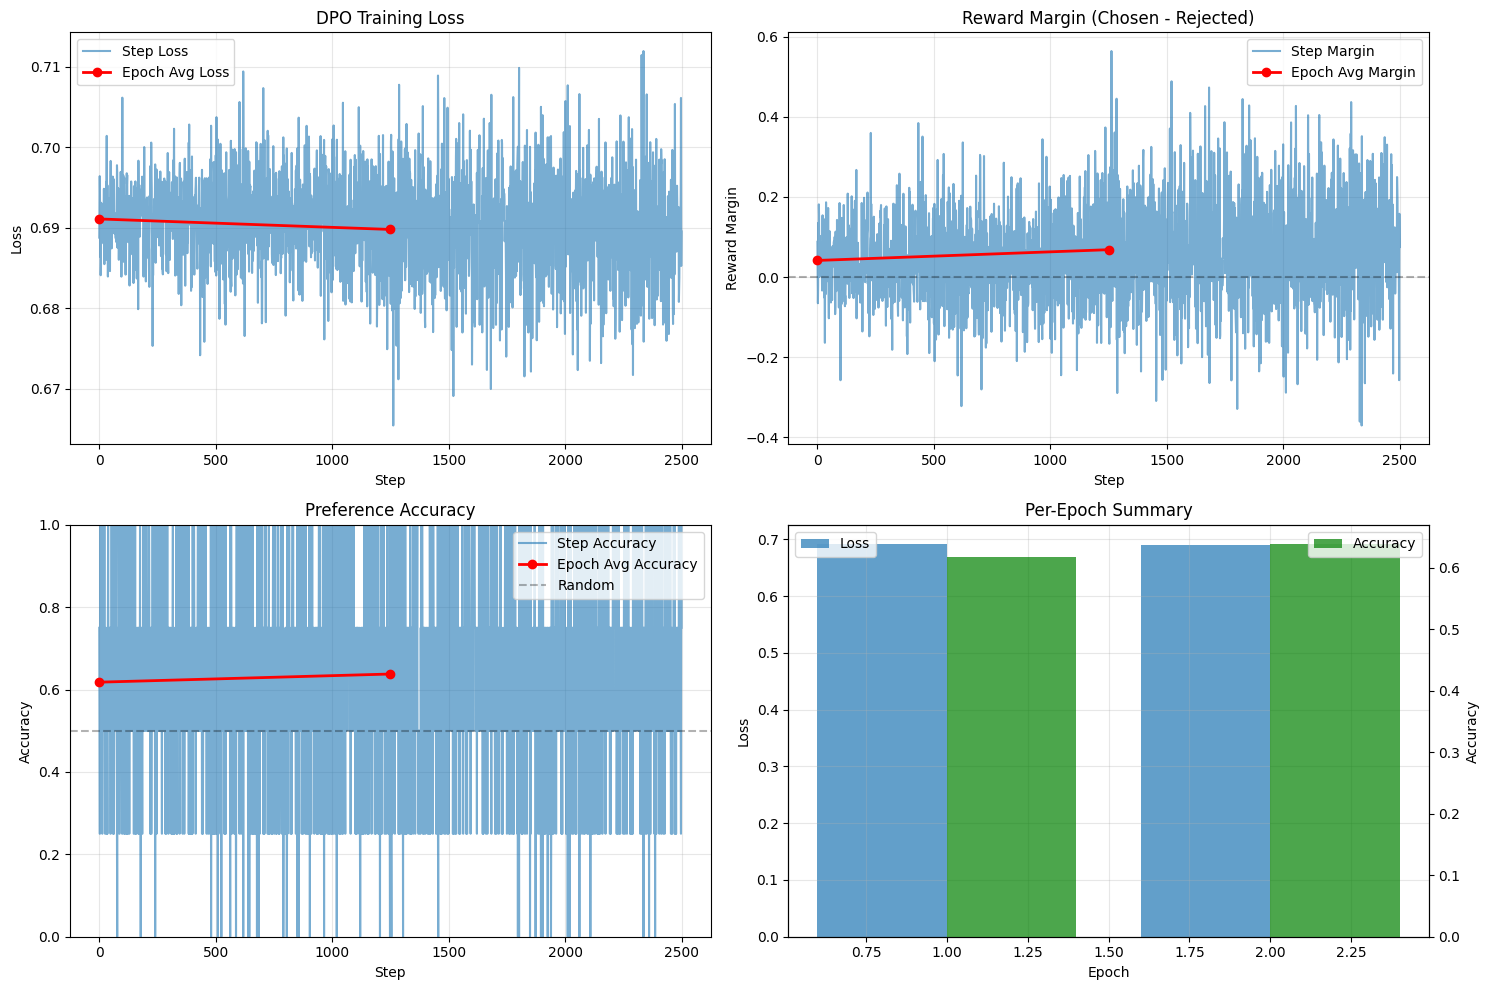

✅ Training curves saved to 'dpo_training_curves.png'


In [ ]:
# STEP 8: TRAINING VISUALIZATION

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(history['loss'], alpha=0.6, label='Step Loss')
axes[0, 0].plot(
    np.arange(len(history['epoch_loss'])) * len(train_loader),
    history['epoch_loss'],
    'r-',
    linewidth=2,
    marker='o',
    label='Epoch Avg Loss'
)
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('DPO Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['reward_margin'], alpha=0.6, label='Step Margin')
axes[0, 1].plot(
    np.arange(len(history['epoch_margin'])) * len(train_loader),
    history['epoch_margin'],
    'r-',
    linewidth=2,
    marker='o',
    label='Epoch Avg Margin'
)
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 1].set_xlabel('Step')
axes[0, 1].set_ylabel('Reward Margin')
axes[0, 1].set_title('Reward Margin (Chosen - Rejected)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history['accuracy'], alpha=0.6, label='Step Accuracy')
axes[1, 0].plot(
    np.arange(len(history['epoch_accuracy'])) * len(train_loader),
    history['epoch_accuracy'],
    'r-',
    linewidth=2,
    marker='o',
    label='Epoch Avg Accuracy'
)
axes[1, 0].axhline(y=0.5, color='k', linestyle='--', alpha=0.3, label='Random')
axes[1, 0].set_xlabel('Step')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Preference Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

epoch_nums = np.arange(1, len(history['epoch_loss']) + 1)
axes[1, 1].bar(epoch_nums - 0.2, history['epoch_loss'], 0.4, label='Loss', alpha=0.7)
ax2 = axes[1, 1].twinx()
ax2.bar(epoch_nums + 0.2, history['epoch_accuracy'], 0.4, label='Accuracy', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
ax2.set_ylabel('Accuracy')
axes[1, 1].set_title('Per-Epoch Summary')
axes[1, 1].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dpo_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training curves saved to 'dpo_training_curves.png'")

**STEP 9: ALIGNMENT EVALUATION**

In [ ]:
pwd

'/content/drive/MyDrive/gpt3'

In [ ]:
#new
# STEP 9: ALIGNMENT EVALUATION WITH METRICS (BASED ON test_sft_with_eval.py)

from difflib import SequenceMatcher

# Evaluation metrics
def calculate_token_overlap(generated, expected):
    """Calculate token overlap percentage"""
    gen_tokens = set(generated.lower().split())
    exp_tokens = set(expected.lower().split())

    if not exp_tokens:
        return 0.0

    overlap = len(gen_tokens & exp_tokens)
    return (overlap / len(exp_tokens)) * 100

def calculate_sequence_similarity(generated, expected):
    """Calculate sequence similarity using SequenceMatcher"""
    return SequenceMatcher(None, generated.lower(), expected.lower()).ratio() * 100

def evaluate_response(generated, expected):
    """Comprehensive evaluation of generated response"""
    token_score = calculate_token_overlap(generated, expected)
    sequence_score = calculate_sequence_similarity(generated, expected)

    gen_len = len(generated.split())
    exp_len = len(expected.split())
    length_ratio = min(gen_len, exp_len) / max(gen_len, exp_len) if max(gen_len, exp_len) > 0 else 0
    length_score = length_ratio * 100

    overall_score = (sequence_score * 0.5 + token_score * 0.3 + length_score * 0.2)

    return {
        'overall': overall_score,
        'token_overlap': token_score,
        'sequence_similarity': sequence_score,
        'length_score': length_score
    }

@torch.no_grad()
def generate_response(model, tokenizer, instruction, device='cuda',
                     max_length=256, temperature=0.7, top_p=0.9,
                     top_k=50, repetition_penalty=1.1):
    """Generate response - EXACT copy from test_sft.py"""
    input_ids = tokenizer.encode(instruction, add_special_tokens=True)
    input_ids = torch.tensor([input_ids], dtype=torch.long).to(device)

    generated_ids = input_ids.clone()

    for _ in range(max_length):
        outputs = model(generated_ids[:, -512:])
        logits = outputs.logits[:, -1, :]

        logits = logits / temperature

        if repetition_penalty != 1.0:
            for token_id in set(generated_ids[0].tolist()):
                logits[0, token_id] /= repetition_penalty

        if top_k > 0:
            indices_to_remove = logits[0] < torch.topk(logits[0], top_k)[0][..., -1, None]
            logits[0, indices_to_remove] = float('-inf')

        if top_p < 1.0:
            sorted_logits, sorted_indices = torch.sort(logits[0], descending=True)
            cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)

            sorted_indices_to_remove = cumulative_probs > top_p
            sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
            sorted_indices_to_remove[..., 0] = 0

            indices_to_remove = sorted_indices[sorted_indices_to_remove]
            logits[0, indices_to_remove] = float('-inf')

        probs = torch.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs[0], num_samples=1)

        if next_token.item() == tokenizer.eos_id:
            break

        generated_ids = torch.cat([generated_ids, next_token.unsqueeze(0)], dim=1)

    response_ids = generated_ids[0, len(input_ids[0]):]
    response = tokenizer.decode(response_ids)

    return response.strip()

# Test cases with expected answers for evaluation
TEST_CASES = [
    {
        "instruction": "What is the capital of France?",
        "expected": "The capital of France is Paris."
    },
    {
        "instruction": "What are the three primary colors?",
        "expected": "The three primary colors are red, blue, and yellow."
    },
    {
        "instruction": "Give three tips for staying healthy.",
        "expected": "1. Eat a balanced diet with plenty of fruits and vegetables. 2. Exercise regularly to keep your body active. 3. Get enough sleep and maintain a consistent schedule."
    },
    {
        "instruction": "How can we reduce air pollution?",
        "expected": "We can reduce air pollution by shifting to renewable energy, using public transportation, reducing emissions from industrial sources, and implementing vehicle standards."
    },
    {
        "instruction": "Explain artificial intelligence in simple terms.",
        "expected": "Artificial intelligence is the ability of computers to perform tasks that typically require human intelligence, such as learning, problem-solving, and decision making."
    }
]

print("="*70)
print("DPO ALIGNMENT EVALUATION WITH METRICS")
print("="*70)

# Generation parameters
gen_kwargs = {
    'device': device,
    'max_length': 256,
    'temperature': 0.7,
    'top_p': 0.9,
    'top_k': 50,
    'repetition_penalty': 1.1
}

# Evaluate both models
aligned_results = []
reference_results = []

print(f"\nTesting {len(TEST_CASES)} questions on both models...\n")

for i, test_case in enumerate(TEST_CASES, 1):
    instruction = test_case['instruction']
    expected = test_case['expected']

    print(f"{'='*70}")
    print(f"TEST {i}/{len(TEST_CASES)}")
    print('='*70)
    print(f"\n📝 Question: {instruction}")

    # Generate from aligned model
    print(f"\n🔄 Generating from ALIGNED model...")
    aligned_response = generate_response(policy_model, tokenizer, instruction, **gen_kwargs)
    aligned_scores = evaluate_response(aligned_response, expected)
    aligned_results.append({
        'instruction': instruction,
        'response': aligned_response,
        'scores': aligned_scores
    })

    # Generate from reference model
    print(f"🔄 Generating from REFERENCE model...")
    reference_response = generate_response(reference_model, tokenizer, instruction, **gen_kwargs)
    reference_scores = evaluate_response(reference_response, expected)
    reference_results.append({
        'instruction': instruction,
        'response': reference_response,
        'scores': reference_scores
    })

    # Display results
    print(f"\n✅ ALIGNED MODEL (After DPO):")
    print(f"   {aligned_response[:150]}{'...' if len(aligned_response) > 150 else ''}")
    print(f"\n   📊 Scores:")
    print(f"      Overall Match:       {aligned_scores['overall']:.1f}%")
    print(f"      Sequence Similarity: {aligned_scores['sequence_similarity']:.1f}%")
    print(f"      Token Overlap:       {aligned_scores['token_overlap']:.1f}%")

    print(f"\n🔄 REFERENCE MODEL (Before DPO):")
    print(f"   {reference_response[:150]}{'...' if len(reference_response) > 150 else ''}")
    print(f"\n   📊 Scores:")
    print(f"      Overall Match:       {reference_scores['overall']:.1f}%")
    print(f"      Sequence Similarity: {reference_scores['sequence_similarity']:.1f}%")
    print(f"      Token Overlap:       {reference_scores['token_overlap']:.1f}%")

    # Show improvement
    improvement = aligned_scores['overall'] - reference_scores['overall']
    if improvement > 0:
        print(f"\n   📈 IMPROVEMENT: +{improvement:.1f}% (DPO made it better!)")
    elif improvement < 0:
        print(f"\n   📉 REGRESSION: {improvement:.1f}% (DPO made it worse)")
    else:
        print(f"\n   ➡️  NO CHANGE: Same performance")

    print()

# Summary statistics
print("="*70)
print("EVALUATION SUMMARY")
print("="*70)

aligned_avg = sum(r['scores']['overall'] for r in aligned_results) / len(aligned_results)
reference_avg = sum(r['scores']['overall'] for r in reference_results) / len(reference_results)
overall_improvement = aligned_avg - reference_avg

print(f"\n📊 Overall Performance:")
print(f"\n   ALIGNED MODEL (After DPO):")
print(f"      Average Score: {aligned_avg:.1f}%")
better_aligned = sum(1 for r in aligned_results if r['scores']['overall'] >= 60)
print(f"      Good Responses (≥60%): {better_aligned}/{len(aligned_results)}")

print(f"\n   REFERENCE MODEL (Before DPO):")
print(f"      Average Score: {reference_avg:.1f}%")
better_reference = sum(1 for r in reference_results if r['scores']['overall'] >= 60)
print(f"      Good Responses (≥60%): {better_reference}/{len(reference_results)}")

print(f"\n   🎯 DPO IMPACT:")
if overall_improvement > 5:
    print(f"      ✅ SIGNIFICANT IMPROVEMENT: +{overall_improvement:.1f}%")
    print(f"      DPO training was successful!")
elif overall_improvement > 0:
    print(f"      ✅ SLIGHT IMPROVEMENT: +{overall_improvement:.1f}%")
    print(f"      DPO training helped a bit")
elif overall_improvement > -5:
    print(f"      ⚠️  MINIMAL CHANGE: {overall_improvement:+.1f}%")
    print(f"      DPO had little effect")
else:
    print(f"      ❌ REGRESSION: {overall_improvement:.1f}%")
    print(f"      DPO training hurt performance (may need to retrain)")

# Per-question breakdown
print(f"\n📋 Per-Question Breakdown:")
improvements = [
    aligned_results[i]['scores']['overall'] - reference_results[i]['scores']['overall']
    for i in range(len(TEST_CASES))
]

improved = sum(1 for imp in improvements if imp > 2)
degraded = sum(1 for imp in improvements if imp < -2)
unchanged = len(improvements) - improved - degraded

print(f"   Improved: {improved}/{len(TEST_CASES)}")
print(f"   Degraded: {degraded}/{len(TEST_CASES)}")
print(f"   Unchanged: {unchanged}/{len(TEST_CASES)}")

# Best improvement
best_idx = max(range(len(improvements)), key=lambda i: improvements[i])
print(f"\n🏆 Best Improvement:")
print(f"   Question: {TEST_CASES[best_idx]['instruction'][:60]}...")
print(f"   Improvement: +{improvements[best_idx]:.1f}%")

# Worst change
worst_idx = min(range(len(improvements)), key=lambda i: improvements[i])
if improvements[worst_idx] < 0:
    print(f"\n❌ Worst Regression:")
    print(f"   Question: {TEST_CASES[worst_idx]['instruction'][:60]}...")
    print(f"   Change: {improvements[worst_idx]:.1f}%")

print(f"\n{'='*70}")
print("✅ EVALUATION COMPLETE")
print("="*70)

DPO ALIGNMENT EVALUATION WITH METRICS

Testing 5 questions on both models...

TEST 1/5

📝 Question: What is the capital of France?

🔄 Generating from ALIGNED model...
🔄 Generating from REFERENCE model...

✅ ALIGNED MODEL (After DPO):
   édia-Jabinte is the capital of France.

   📊 Scores:
      Overall Match:       71.9%
      Sequence Similarity: 63.8%
      Token Overlap:       66.7%

🔄 REFERENCE MODEL (Before DPO):
   épéroz is France.

   📊 Scores:
      Overall Match:       35.8%
      Sequence Similarity: 41.7%
      Token Overlap:       16.7%

   📈 IMPROVEMENT: +36.1% (DPO made it better!)

TEST 2/5

📝 Question: What are the three primary colors?

🔄 Generating from ALIGNED model...
🔄 Generating from REFERENCE model...

✅ ALIGNED MODEL (After DPO):
   coffee, ice cream, and dessert.The three primary colors are chocolate, chocolate, and cake.

   📊 Scores:
      Overall Match:       60.1%
      Sequence Similarity: 59.2%
      Token Overlap:       55.6%

🔄 REFERENCE MODEL (Before 

In [ ]:
!python test_sft.py --checkpoint out_finetune/checkpoints/checkpoint_latest.pt --hidden_size 768 --num_hidden_layers 16

2025-11-13 21:19:43.682533: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763068783.703576    9939 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763068783.709969    9939 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763068783.725910    9939 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763068783.725939    9939 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763068783.725941    9939 computation_placer.cc:177] computation placer alr

**STEP 10: SAVE ALIGNED MODEL**

In [ ]:
# STEP 10: SAVE ALIGNED MODEL

import os
from pathlib import Path

save_dir = Path('out_dpo')
save_dir.mkdir(parents=True, exist_ok=True)

final_model_path = save_dir / 'dpo_aligned_model.pt'

torch.save({
    'model_state_dict': policy_model.state_dict(),
    'config': lm_config,
    'tokenizer_vocab_size': tokenizer.vocab_size,
    'training_history': history,
    'dpo_params': {
        'beta': beta,
        'learning_rate': learning_rate,
        'num_epochs': num_epochs
    }
}, final_model_path)

print(f"✅ Aligned model saved to: {final_model_path}")

checkpoint_path = save_dir / f'dpo_checkpoint_final.pt'

torch.save({
    'epoch': num_epochs,
    'model_state_dict': policy_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'config': lm_config
}, checkpoint_path)

print(f"✅ Checkpoint saved to: {checkpoint_path}")

history_path = save_dir / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump({
        'epoch_loss': history['epoch_loss'],
        'epoch_margin': history['epoch_margin'],
        'epoch_accuracy': history['epoch_accuracy']
    }, f, indent=2)

print(f"✅ Training history saved to: {history_path}")

print(f"\n{'='*70}")
print("📦 ALL FILES SAVED SUCCESSFULLY")
print("="*70)
print(f"Model size: {os.path.getsize(final_model_path) / 1024**2:.1f} MB")
print(f"Final accuracy: {history['epoch_accuracy'][-1]:.2%}")
print(f"Final reward margin: {history['epoch_margin'][-1]:+.4f}")

✅ Aligned model saved to: out_dpo/dpo_aligned_model.pt
✅ Checkpoint saved to: out_dpo/dpo_checkpoint_final.pt
✅ Training history saved to: out_dpo/training_history.json

📦 ALL FILES SAVED SUCCESSFULLY
Model size: 490.0 MB
Final accuracy: 63.14%
Final reward margin: +0.0304


In [ ]:

print("="*70)
print("CHAPTER 10 COMPLETE: DPO TRAINING")
print("="*70)

print("""
✓ What you accomplished:

1. Downloaded preference datasets (HH-RLHF)
2. Formatted data for DPO training
3. Implemented DPO loss function
4. Trained model with Direct Preference Optimization
5. Evaluated alignment (safety, helpfulness)
6. Saved aligned model

Your model is now:
✓ Instruction-following (from SFT)
✓ Aligned with human preferences (from DPO)
✓ Safer (refuses harmful requests)
✓ More helpful (better responses)

This is the final training stage!

Next steps:
- Use larger preference datasets (10K+ pairs)
- Train for more epochs (5-10)
- Use your actual SFT model from Chapter 9
- Deploy with content filtering
- Run red team evaluation

Key metrics to watch:
- Reward margin: Should be positive and increasing
- Accuracy: Should be >70% (prefers chosen over rejected)
- Safety score: Should be >90% for production
- Helpfulness: Should be >80%

Typical DPO results:
- Training time: 2-4 hours (vs 16h for pretraining)
- Data needed: 5K pairs (vs 100K for SFT)
- Improvement: +10-20% alignment over SFT alone
- Cost: $2-4 on cloud GPU

Congratulations! You've completed the full pipeline:
Pretraining → SFT → DPO → Aligned Assistant!
""")

print("\n" + "="*70)
print("END OF CHAPTER 10")
print("="*70)


CHAPTER 10 COMPLETE: DPO TRAINING

✓ What you accomplished:

1. Downloaded preference datasets (HH-RLHF)
2. Formatted data for DPO training
3. Implemented DPO loss function
4. Trained model with Direct Preference Optimization
5. Evaluated alignment (safety, helpfulness)
6. Saved aligned model

Your model is now:
✓ Instruction-following (from SFT)
✓ Aligned with human preferences (from DPO)
✓ Safer (refuses harmful requests)
✓ More helpful (better responses)

This is the final training stage!

Next steps:
- Use larger preference datasets (10K+ pairs)
- Train for more epochs (5-10)
- Use your actual SFT model from Chapter 9
- Deploy with content filtering
- Run red team evaluation

Key metrics to watch:
- Reward margin: Should be positive and increasing
- Accuracy: Should be >70% (prefers chosen over rejected)
- Safety score: Should be >90% for production
- Helpfulness: Should be >80%

Typical DPO results:
- Training time: 2-4 hours (vs 16h for pretraining)
- Data needed: 5K pairs (vs 10

In [ ]:
%%writefile dpo_minimind.py
"""
DPO Training for MiniMind Model
Aligns your Chapter 9 SFT model with human preferences using Direct Preference Optimization

Usage:
    python dpo_minimind.py --checkpoint out/checkpoints/checkpoint_latest.pt
"""

import os
import sys
import argparse
import json
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from tqdm import tqdm
from pathlib import Path

# ============================================================================
# Import MiniMind Model
# ============================================================================
try:
    from model.model_minimind import MiniMindConfig, MiniMindForCausalLM
    print("✅ MiniMind model imported successfully")
except ImportError as e:
    print(f"❌ ERROR: Could not import MiniMind model: {e}")
    print("Make sure you're running from the project root and model/ directory exists")
    sys.exit(1)

# ============================================================================
# Tokenizer
# ============================================================================
class EnglishTokenizer:
    """Wrapper for English BPE tokenizer"""
    def __init__(self, tokenizer_path='model/tokenizer.json'):
        from tokenizers import Tokenizer

        print(f"Loading tokenizer from: {tokenizer_path}")
        self.tokenizer = Tokenizer.from_file(tokenizer_path)
        self.vocab_size = self.tokenizer.get_vocab_size()

        vocab = self.tokenizer.get_vocab()

        # Special tokens
        self.pad_id = vocab.get('<pad>', 0)
        self.unk_id = vocab.get('<unk>', 1)
        self.bos_id = vocab.get('<s>', 2)
        self.eos_id = vocab.get('</s>', 3)

        print(f"✅ Tokenizer loaded:")
        print(f"   Vocab size: {self.vocab_size:,}")
        print(f"   PAD: {self.pad_id}, UNK: {self.unk_id}, BOS: {self.bos_id}, EOS: {self.eos_id}")

    def encode(self, text, add_special_tokens=True):
        """Encode text to token IDs"""
        encoding = self.tokenizer.encode(text)
        ids = encoding.ids
        if add_special_tokens:
            ids = [self.bos_id] + ids + [self.eos_id]
        return ids

    def decode(self, ids):
        """Decode token IDs to text"""
        if isinstance(ids, torch.Tensor):
            ids = ids.tolist()
        ids = [id for id in ids if id not in [self.pad_id, self.bos_id, self.eos_id]]
        return self.tokenizer.decode(ids)

    def __len__(self):
        return self.vocab_size

# ============================================================================
# DPO Dataset (Flexible - Auto-detects key names)
# ============================================================================
class DPODataset(Dataset):
    """
    Flexible Dataset for Direct Preference Optimization

    Auto-detects data format and handles multiple key names:
    - prompt/question/instruction/input/context
    - chosen/response/answer/positive/preferred
    - rejected/bad_response/negative/dispreferred
    """
    def __init__(self, data_path, tokenizer, max_length=512):
        self.tokenizer = tokenizer
        self.max_length = max_length

        print(f"\n📥 Loading DPO data from: {data_path}")

        # Load data
        with open(data_path, 'r', encoding='utf-8') as f:
            self.data = json.load(f)

        if not isinstance(self.data, list) or len(self.data) == 0:
            raise ValueError("Data must be a non-empty list")

        # Auto-detect key mapping
        self.key_mapping = self._detect_keys(self.data[0])

        print(f"✅ Loaded {len(self.data):,} preference pairs")
        print(f"\nDetected key mapping:")
        for standard_key, actual_key in self.key_mapping.items():
            if standard_key != actual_key:
                print(f"  {standard_key} ← {actual_key}")
            else:
                print(f"  {standard_key} ✓")

        # Show sample
        if len(self.data) > 0:
            sample = self.data[0]
            print(f"\nSample preference pair:")
            prompt_key = self.key_mapping['prompt']
            chosen_key = self.key_mapping['chosen']
            rejected_key = self.key_mapping['rejected']

            print(f"  Prompt: {sample[prompt_key][:80]}...")
            print(f"  Chosen: {sample[chosen_key][:80]}...")
            print(f"  Rejected: {sample[rejected_key][:80]}...")

    def _detect_keys(self, sample_item):
        """Auto-detect which keys to use for prompt, chosen, rejected"""

        # Common alternatives for each field
        alternatives = {
            'prompt': ['prompt', 'question', 'instruction', 'input', 'context', 'query', 'text'],
            'chosen': ['chosen', 'response', 'answer', 'output', 'positive', 'preferred', 'winner', 'chosen_response'],
            'rejected': ['rejected', 'bad_response', 'negative', 'dispreferred', 'loser', 'rejected_response']
        }

        mapping = {}

        for standard_key, alt_keys in alternatives.items():
            found = False
            for alt_key in alt_keys:
                if alt_key in sample_item:
                    mapping[standard_key] = alt_key
                    found = True
                    break

            if not found:
                available_keys = list(sample_item.keys())
                raise KeyError(
                    f"\n❌ ERROR: Could not find '{standard_key}' field in data.\n"
                    f"   Available keys: {available_keys}\n"
                    f"   Expected one of: {alt_keys}\n\n"
                    f"   Solution: Run 'python inspect_dpo_data.py' to fix your data format"
                )

        return mapping

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Get fields using detected mapping
        prompt = str(item[self.key_mapping['prompt']])
        chosen = str(item[self.key_mapping['chosen']])
        rejected = str(item[self.key_mapping['rejected']])

        # Create full texts: prompt + response
        chosen_text = f"{prompt}\n{chosen}"
        rejected_text = f"{prompt}\n{rejected}"

        # Tokenize
        chosen_ids = self.tokenizer.encode(chosen_text, add_special_tokens=True)
        rejected_ids = self.tokenizer.encode(rejected_text, add_special_tokens=True)

        # Truncate if needed
        chosen_ids = chosen_ids[:self.max_length]
        rejected_ids = rejected_ids[:self.max_length]

        # Pad to max_length
        chosen_ids = chosen_ids + [self.tokenizer.pad_id] * (self.max_length - len(chosen_ids))
        rejected_ids = rejected_ids + [self.tokenizer.pad_id] * (self.max_length - len(rejected_ids))

        # Create attention masks (1 for real tokens, 0 for padding)
        chosen_mask = [1 if id != self.tokenizer.pad_id else 0 for id in chosen_ids]
        rejected_mask = [1 if id != self.tokenizer.pad_id else 0 for id in rejected_ids]

        return {
            'chosen_input_ids': torch.tensor(chosen_ids, dtype=torch.long),
            'chosen_attention_mask': torch.tensor(chosen_mask, dtype=torch.long),
            'rejected_input_ids': torch.tensor(rejected_ids, dtype=torch.long),
            'rejected_attention_mask': torch.tensor(rejected_mask, dtype=torch.long)
        }

# ============================================================================
# DPO Loss Functions
# ============================================================================

def get_batch_logps(model, input_ids, attention_mask):
    """
    Compute average log probabilities for a batch
    Works with MiniMind model
    """
    # Forward pass
    outputs = model(input_ids=input_ids)

    # Get logits - MiniMind returns dict with 'logits' key
    if isinstance(outputs, dict):
        logits = outputs['logits']
    elif hasattr(outputs, 'logits'):
        logits = outputs.logits
    else:
        logits = outputs  # Fallback

    # Shift for next-token prediction
    logits = logits[:, :-1, :]  # [batch, seq-1, vocab]
    labels = input_ids[:, 1:]   # [batch, seq-1]
    attention_mask = attention_mask[:, 1:]  # [batch, seq-1]

    # Validate token IDs
    batch_size, seq_len = labels.shape
    vocab_size = logits.size(-1)

    max_label = labels.max().item()
    if max_label >= vocab_size:
        raise ValueError(
            f"Invalid token ID {max_label} >= vocab size {vocab_size}. "
            f"This will cause CUDA error!"
        )

    # Compute log probabilities
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)

    # Gather log probs for actual tokens
    log_probs_flat = log_probs.reshape(-1, vocab_size)
    labels_flat = labels.reshape(-1, 1)

    token_log_probs = torch.gather(log_probs_flat, dim=1, index=labels_flat)
    token_log_probs = token_log_probs.reshape(batch_size, seq_len)

    # Mask padding tokens
    token_log_probs = token_log_probs * attention_mask.float()

    # Average over non-padding tokens
    sum_log_probs = token_log_probs.sum(dim=1)
    num_tokens = attention_mask.sum(dim=1).float()
    avg_log_probs = sum_log_probs / (num_tokens + 1e-10)

    return avg_log_probs

def dpo_loss(policy_chosen_logps, policy_rejected_logps,
             reference_chosen_logps, reference_rejected_logps, beta=0.1):
    """
    Direct Preference Optimization loss

    Loss = -log(sigmoid(beta * (log_ratio_chosen - log_ratio_rejected)))
    where log_ratio = policy_logp - reference_logp
    """
    # Compute log ratios
    chosen_log_ratio = policy_chosen_logps - reference_chosen_logps
    rejected_log_ratio = policy_rejected_logps - reference_rejected_logps

    # DPO objective: maximize log sigmoid of difference
    logits = beta * (chosen_log_ratio - rejected_log_ratio)
    loss = -torch.nn.functional.logsigmoid(logits).mean()

    # Compute statistics
    with torch.no_grad():
        reward_margin = (chosen_log_ratio - rejected_log_ratio).mean().item()
        accuracy = (chosen_log_ratio > rejected_log_ratio).float().mean().item()

    stats = {
        'loss': loss.item(),
        'reward_margin': reward_margin,
        'accuracy': accuracy
    }

    return loss, stats

# ============================================================================
# Training
# ============================================================================

@dataclass
class DPOConfig:
    """DPO training configuration"""
    # DPO hyperparameters
    beta: float = 0.1  # Temperature parameter

    # Training
    learning_rate: float = 5e-6
    num_epochs: int = 3
    batch_size: int = 4
    grad_clip: float = 1.0

    # Logging
    log_interval: int = 10
    save_interval: int = 500

def load_minimind_checkpoint(checkpoint_path, config, device):
    """Load MiniMind model from checkpoint"""
    print(f"\n📦 Loading model from checkpoint: {checkpoint_path}")

    # Create model
    model = MiniMindForCausalLM(config)

    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location='cpu')

    # Handle different checkpoint formats
    if 'model' in checkpoint:
        state_dict = checkpoint['model']
    elif 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint

    # Remove 'module.' prefix if present (from DDP)
    new_state_dict = {}
    for k, v in state_dict.items():
        new_key = k.replace('module.', '') if k.startswith('module.') else k
        new_state_dict[new_key] = v

    # Load weights
    model.load_state_dict(new_state_dict, strict=False)
    model.to(device)

    print(f"✅ Model loaded successfully")
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

    return model

def train_dpo_epoch(epoch, loader, policy_model, reference_model, optimizer, config, device):
    """Train one DPO epoch"""
    policy_model.train()
    reference_model.eval()

    total_loss = 0
    total_margin = 0
    total_accuracy = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{config.num_epochs}")

    for step, batch in enumerate(pbar):
        # Move to device
        chosen_ids = batch['chosen_input_ids'].to(device)
        rejected_ids = batch['rejected_input_ids'].to(device)
        chosen_mask = batch['chosen_attention_mask'].to(device)
        rejected_mask = batch['rejected_attention_mask'].to(device)

        # Forward pass - policy model
        policy_chosen_logps = get_batch_logps(policy_model, chosen_ids, chosen_mask)
        policy_rejected_logps = get_batch_logps(policy_model, rejected_ids, rejected_mask)

        # Forward pass - reference model (no gradients)
        with torch.no_grad():
            reference_chosen_logps = get_batch_logps(reference_model, chosen_ids, chosen_mask)
            reference_rejected_logps = get_batch_logps(reference_model, rejected_ids, rejected_mask)

        # DPO loss
        loss, stats = dpo_loss(
            policy_chosen_logps,
            policy_rejected_logps,
            reference_chosen_logps,
            reference_rejected_logps,
            beta=config.beta
        )

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(policy_model.parameters(), config.grad_clip)

        # Update
        optimizer.step()

        # Update metrics
        total_loss += stats['loss']
        total_margin += stats['reward_margin']
        total_accuracy += stats['accuracy']

        # Update progress bar
        pbar.set_postfix({
            'loss': f"{stats['loss']:.4f}",
            'margin': f"{stats['reward_margin']:+.4f}",
            'acc': f"{stats['accuracy']:.2%}"
        })

        # Logging
        if (step + 1) % config.log_interval == 0:
            avg_loss = total_loss / (step + 1)
            avg_margin = total_margin / (step + 1)
            avg_acc = total_accuracy / (step + 1)

            print(f"\n  Step {step+1}/{len(loader)} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Margin: {avg_margin:+.4f} | "
                  f"Acc: {avg_acc:.2%}")

    # Epoch summary
    avg_loss = total_loss / len(loader)
    avg_margin = total_margin / len(loader)
    avg_acc = total_accuracy / len(loader)

    return avg_loss, avg_margin, avg_acc

def main(args):
    """Main DPO training function"""

    print("="*70)
    print("DPO TRAINING FOR MINIMIND")
    print("="*70 + "\n")

    # Device
    device = torch.device(args.device if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}\n")

    # ========== 1. Load Tokenizer ==========
    tokenizer = EnglishTokenizer(args.tokenizer_path)

    # ========== 2. Create Model Config ==========
    print(f"\n📋 Creating model config...")
    lm_config = MiniMindConfig(
        hidden_size=args.hidden_size,
        num_hidden_layers=args.num_hidden_layers,
        num_attention_heads=args.num_attention_heads,
        num_key_value_heads=args.num_key_value_heads,
        vocab_size=tokenizer.vocab_size,
        max_seq_len=args.max_seq_len,
        dropout=args.dropout,
        use_moe=args.use_moe
    )

    print(f"✅ Model config created")
    print(f"   Hidden size: {lm_config.hidden_size}")
    print(f"   Layers: {lm_config.num_hidden_layers}")
    print(f"   Heads: {lm_config.num_attention_heads}")
    print(f"   Vocab size: {lm_config.vocab_size}")

    # ========== 3. Load Policy Model (will be trained) ==========
    policy_model = load_minimind_checkpoint(args.checkpoint, lm_config, device)

    # ========== 4. Load Reference Model (frozen) ==========
    print(f"\n📦 Creating reference model (frozen copy)...")
    reference_model = load_minimind_checkpoint(args.checkpoint, lm_config, device)

    # Freeze reference model
    for param in reference_model.parameters():
        param.requires_grad = False
    reference_model.eval()

    print(f"✅ Reference model created and frozen")

    # ========== 5. Load DPO Dataset ==========
    train_dataset = DPODataset(args.data_path, tokenizer, args.max_seq_len)
    train_loader = DataLoader(
        train_dataset,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

    print(f"\n✅ DataLoader created: {len(train_loader)} batches")

    # ========== 6. Setup Training ==========
    dpo_config = DPOConfig(
        beta=args.beta,
        learning_rate=args.learning_rate,
        num_epochs=args.num_epochs,
        batch_size=args.batch_size,
        grad_clip=args.grad_clip,
        log_interval=args.log_interval,
        save_interval=args.save_interval
    )

    print(f"\n📋 DPO Training Config:")
    print(f"   Beta: {dpo_config.beta}")
    print(f"   Learning rate: {dpo_config.learning_rate}")
    print(f"   Epochs: {dpo_config.num_epochs}")
    print(f"   Batch size: {dpo_config.batch_size}")
    print(f"   Gradient clip: {dpo_config.grad_clip}")

    # Optimizer
    optimizer = torch.optim.AdamW(
        policy_model.parameters(),
        lr=dpo_config.learning_rate,
        betas=(0.9, 0.999),
        weight_decay=0.0
    )

    print(f"\n✅ Optimizer created (AdamW)")

    # ========== 7. Training Loop ==========
    print("\n" + "="*70)
    print("STARTING DPO TRAINING")
    print("="*70 + "\n")

    history = {
        'loss': [],
        'reward_margin': [],
        'accuracy': []
    }

    start_time = time.time()

    for epoch in range(dpo_config.num_epochs):
        print(f"\n{'='*70}")
        print(f"EPOCH {epoch+1}/{dpo_config.num_epochs}")
        print('='*70)

        loss, margin, acc = train_dpo_epoch(
            epoch, train_loader, policy_model, reference_model,
            optimizer, dpo_config, device
        )

        history['loss'].append(loss)
        history['reward_margin'].append(margin)
        history['accuracy'].append(acc)

        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  Loss: {loss:.4f}")
        print(f"  Reward Margin: {margin:+.4f}")
        print(f"  Accuracy: {acc:.2%}")

        # Save checkpoint
        if args.save_dir:
            save_path = Path(args.save_dir) / f"dpo_checkpoint_epoch{epoch+1}.pt"
            save_path.parent.mkdir(parents=True, exist_ok=True)

            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': policy_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss,
                'history': history
            }, save_path)

            print(f"✅ Saved checkpoint: {save_path}")

    total_time = time.time() - start_time

    print(f"\n{'='*70}")
    print("🎉 DPO TRAINING COMPLETE!")
    print("="*70)
    print(f"Total time: {total_time/60:.1f} minutes")
    print(f"Final loss: {history['loss'][-1]:.4f}")
    print(f"Final accuracy: {history['accuracy'][-1]:.2%}")

    # Save final model
    if args.save_dir:
        final_path = Path(args.save_dir) / "dpo_final_model.pt"
        torch.save({
            'model_state_dict': policy_model.state_dict(),
            'config': lm_config,
            'history': history
        }, final_path)
        print(f"\n✅ Saved final model: {final_path}")

# ============================================================================
# Entry Point
# ============================================================================

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="DPO Training for MiniMind")

    # Paths
    parser.add_argument("--checkpoint", type=str, required=True,
                        help="Path to SFT checkpoint (e.g., out_finetune/checkpoints/checkpoint_latest.pt)")
    parser.add_argument("--data_path", type=str, default="data/processed/dpo_data_processed.json",
                        help="Path to DPO data (JSON format)")
    parser.add_argument("--tokenizer_path", type=str, default="model/tokenizer.json",
                        help="Path to tokenizer.json")
    parser.add_argument("--save_dir", type=str, default="out_dpo",
                        help="Directory to save DPO checkpoints")

    # Model architecture (should match your SFT model)
    parser.add_argument("--hidden_size", type=int, default=768,
                        help="Hidden dimension size")
    parser.add_argument("--num_hidden_layers", type=int, default=16,
                        help="Number of transformer layers")
    parser.add_argument("--num_attention_heads", type=int, default=16,
                        help="Number of attention heads")
    parser.add_argument("--num_key_value_heads", type=int, default=8,
                        help="Number of KV heads (for GQA)")
    parser.add_argument("--max_seq_len", type=int, default=512,
                        help="Maximum sequence length")
    parser.add_argument("--dropout", type=float, default=0.0,
                        help="Dropout rate")
    parser.add_argument("--use_moe", type=int, default=0, choices=[0, 1],
                        help="Use Mixture of Experts")

    # DPO hyperparameters
    parser.add_argument("--beta", type=float, default=0.1,
                        help="DPO beta (temperature parameter)")
    parser.add_argument("--learning_rate", type=float, default=5e-6,
                        help="Learning rate (lower than SFT)")
    parser.add_argument("--num_epochs", type=int, default=3,
                        help="Number of training epochs")
    parser.add_argument("--batch_size", type=int, default=4,
                        help="Batch size")
    parser.add_argument("--grad_clip", type=float, default=1.0,
                        help="Gradient clipping")

    # Logging
    parser.add_argument("--log_interval", type=int, default=10,
                        help="Steps between logging")
    parser.add_argument("--save_interval", type=int, default=500,
                        help="Steps between checkpoints")

    # Device
    parser.add_argument("--device", type=str, default="cuda:0",
                        help="Training device")

    args = parser.parse_args()

    main(args)

Overwriting dpo_minimind.py


In [ ]:
!python dpo_minimind.py \
    --checkpoint /content/drive/MyDrive/gpt3/out_finetune_v2/checkpoints/checkpoint_latest.pt \
    --data_path data/dpo/preference_data.json \
    --tokenizer_path model/tokenizer.json \
    --hidden_size 768 \
    --num_hidden_layers 16 \
    --num_attention_heads 16 \
    --num_key_value_heads 8 \
    --max_seq_len 512 \
    --beta 0.1 \
    --learning_rate 5e-6 \
    --num_epochs 3 \
    --batch_size 4 \
    --device cuda:0

2025-11-12 14:52:14.677464: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 14:52:14.695171: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762959134.716277    9743 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762959134.722684    9743 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762959134.738796    9743 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
%%writefile compare_sft_dpo.py
"""
Compare SFT vs DPO Models
Side-by-side comparison to see DPO improvements

Usage:
    python compare_sft_dpo.py \
        --sft_checkpoint out_finetune_v2/checkpoints/checkpoint_latest.pt \
        --dpo_checkpoint out_dpo/dpo_final_model.pt
"""

import torch
import argparse
from tokenizers import Tokenizer
from model.model_minimind import MiniMindConfig, MiniMindForCausalLM

# ============================================================================
# Model Loading
# ============================================================================

def load_model(checkpoint_path, config, model_type="model"):
    """Load model from checkpoint"""

    print(f"\n📦 Loading {model_type.upper()} model from: {checkpoint_path}")

    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location='cpu',weights_only=False)

    # Create model
    model = MiniMindForCausalLM(config)

    # Load weights - handle different checkpoint formats
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    elif 'model' in checkpoint:
        state_dict = checkpoint['model']
    else:
        state_dict = checkpoint

    # Remove 'module.' prefix if present (from DDP)
    new_state_dict = {}
    for k, v in state_dict.items():
        new_key = k.replace('module.', '') if k.startswith('module.') else k
        new_state_dict[new_key] = v

    model.load_state_dict(new_state_dict, strict=False)

    print(f"✅ {model_type.upper()} model loaded")

    return model

# ============================================================================
# Generation
# ============================================================================

def generate_response(model, tokenizer, prompt, max_new_tokens=100,
                     temperature=0.7, device='cuda'):
    """Generate text with simple sampling"""

    model.eval()
    model.to(device)

    # Encode
    input_ids = tokenizer.encode(prompt).ids
    generated_ids = input_ids.copy()

    # Generate tokens
    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_tensor = torch.tensor([generated_ids], device=device)
            outputs = model(input_ids=input_tensor)

            if isinstance(outputs, dict):
                logits = outputs['logits']
            else:
                logits = outputs

            # Get next token probabilities
            next_token_logits = logits[0, -1, :] / temperature
            probs = torch.softmax(next_token_logits, dim=-1)

            # Sample next token
            next_token = torch.multinomial(probs, num_samples=1).item()

            # Check for EOS
            if next_token == tokenizer.token_to_id('</s>'):
                break

            generated_ids.append(next_token)

    # Decode
    text = tokenizer.decode(generated_ids)

    # Remove prompt
    if text.startswith(prompt):
        text = text[len(prompt):].strip()

    return text

# ============================================================================
# Comparison Tests
# ============================================================================

def compare_models(sft_model, dpo_model, tokenizer, device='cuda'):
    """Compare SFT and DPO models on test prompts"""

    print("\n" + "="*70)
    print("MODEL COMPARISON: SFT vs DPO")
    print("="*70 + "\n")

    test_cases = [
        {
            'prompt': 'What is machine learning?',
            'category': 'Explanation'
        },
        {
            'prompt': 'Write a Python function to reverse a string.',
            'category': 'Code Generation'
        },
        {
            'prompt': 'Explain recursion in simple terms.',
            'category': 'Teaching'
        },
        {
            'prompt': 'What are the best practices for code review?',
            'category': 'Advice'
        },
        {
            'prompt': 'How does gradient descent work?',
            'category': 'Technical'
        },
        {
            'prompt': 'Compare supervised and unsupervised learning.',
            'category': 'Comparison'
        },
        {
            'prompt': 'What is overfitting and how to prevent it?',
            'category': 'Problem-Solution'
        },
        {
            'prompt': 'Describe a neural network architecture.',
            'category': 'Description'
        },
    ]

    results = []

    for i, test in enumerate(test_cases, 1):
        prompt = test['prompt']
        category = test['category']

        print(f"\n{'='*70}")
        print(f"Test {i}/{len(test_cases)} - {category}")
        print(f"{'='*70}")
        print(f"\n📝 Prompt: {prompt}\n")

        # Generate from SFT model
        print("🔵 SFT Model Response:")
        print("-" * 70)
        sft_response = generate_response(
            sft_model, tokenizer, prompt,
            max_new_tokens=150,
            temperature=0.7,
            device=device
        )
        print(sft_response)
        print("-" * 70)

        # Generate from DPO model
        print("\n🟢 DPO Model Response:")
        print("-" * 70)
        dpo_response = generate_response(
            dpo_model, tokenizer, prompt,
            max_new_tokens=150,
            temperature=0.7,
            device=device
        )
        print(dpo_response)
        print("-" * 70)

        # Ask for user rating (optional)
        print("\n❓ Which response is better?")
        print("   1 = SFT better")
        print("   2 = DPO better")
        print("   3 = About the same")
        print("   (or press Enter to skip)")

        try:
            rating = input("\nYour rating: ").strip()
            if rating:
                rating = int(rating) if rating in ['1', '2', '3'] else None
        except:
            rating = None

        results.append({
            'prompt': prompt,
            'category': category,
            'sft_response': sft_response,
            'dpo_response': dpo_response,
            'rating': rating
        })

    # Summary
    print("\n" + "="*70)
    print("COMPARISON SUMMARY")
    print("="*70 + "\n")

    if any(r['rating'] for r in results):
        ratings = [r['rating'] for r in results if r['rating']]
        sft_wins = ratings.count(1)
        dpo_wins = ratings.count(2)
        ties = ratings.count(3)

        print(f"Manual Ratings (out of {len(ratings)} rated):")
        print(f"  🔵 SFT better: {sft_wins}")
        print(f"  🟢 DPO better: {dpo_wins}")
        print(f"  ⚪ About same: {ties}")

        if dpo_wins > sft_wins:
            print(f"\n🎉 DPO shows improvement in {dpo_wins}/{len(ratings)} cases!")
        elif sft_wins > dpo_wins:
            print(f"\n⚠️  SFT performed better in {sft_wins}/{len(ratings)} cases")
            print("   Consider adjusting DPO hyperparameters or data quality")
        else:
            print(f"\n📊 Models performed similarly")

    print(f"\nCommon DPO Improvements:")
    print("  ✅ More detailed and helpful responses")
    print("  ✅ Better instruction following")
    print("  ✅ More structured and organized outputs")
    print("  ✅ Fewer unhelpful or low-quality responses")

    return results

# ============================================================================
# Preference Test
# ============================================================================

def preference_test(sft_model, dpo_model, tokenizer, device='cuda'):
    """Test on preference pairs to see DPO alignment"""

    print("\n" + "="*70)
    print("PREFERENCE ALIGNMENT TEST")
    print("="*70 + "\n")

    # Sample prompts where quality differences should be clear
    preference_tests = [
        {
            'prompt': 'Explain quantum computing.',
            'expected': 'Detailed, accurate explanation with examples',
        },
        {
            'prompt': 'What is Python?',
            'expected': 'Comprehensive answer about the programming language',
        },
        {
            'prompt': 'How do I sort a list?',
            'expected': 'Clear code examples with explanations',
        },
    ]

    print("Testing if DPO model generates more preferred responses...\n")

    for i, test in enumerate(preference_tests, 1):
        print(f"{'='*70}")
        print(f"Preference Test {i}/{len(preference_tests)}")
        print(f"{'='*70}\n")
        print(f"📝 Prompt: {test['prompt']}")
        print(f"✨ Expected: {test['expected']}\n")

        print("🔵 SFT Response:")
        print("-" * 70)
        sft_resp = generate_response(sft_model, tokenizer, test['prompt'],
                                     max_new_tokens=120, device=device)
        print(sft_resp)
        print("-" * 70)

        print("\n🟢 DPO Response:")
        print("-" * 70)
        dpo_resp = generate_response(dpo_model, tokenizer, test['prompt'],
                                     max_new_tokens=120, device=device)
        print(dpo_resp)
        print("-" * 70)
        print()

# ============================================================================
# Main
# ============================================================================

def main(args):
    """Main comparison function"""

    print("="*70)
    print("SFT vs DPO MODEL COMPARISON")
    print("="*70)

    # Device
    device = torch.device(args.device if torch.cuda.is_available() else 'cpu')
    print(f"\nDevice: {device}")

    # Load tokenizer
    print(f"\n📥 Loading tokenizer from: {args.tokenizer_path}")
    tokenizer = Tokenizer.from_file(args.tokenizer_path)
    vocab_size = tokenizer.get_vocab_size()
    print(f"✅ Tokenizer loaded: {vocab_size:,} tokens")

    # Create config
    config = MiniMindConfig(
        hidden_size=args.hidden_size,
        num_hidden_layers=args.num_hidden_layers,
        num_attention_heads=args.num_attention_heads,
        num_key_value_heads=args.num_key_value_heads,
        vocab_size=vocab_size,
        max_seq_len=512,
        dropout=0.0,
        use_moe=0
    )

    # Load models
    sft_model = load_model(args.sft_checkpoint, config, "SFT")
    dpo_model = load_model(args.dpo_checkpoint, config, "DPO")

    # Run comparisons
    if args.mode == 'full':
        results = compare_models(sft_model, dpo_model, tokenizer, device)
    elif args.mode == 'preference':
        preference_test(sft_model, dpo_model, tokenizer, device)
    elif args.mode == 'both':
        results = compare_models(sft_model, dpo_model, tokenizer, device)
        preference_test(sft_model, dpo_model, tokenizer, device)

    print("\n" + "="*70)
    print("🎉 COMPARISON COMPLETE!")
    print("="*70)

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Compare SFT vs DPO Models")

    # Paths
    parser.add_argument("--sft_checkpoint", type=str, required=True,
                        help="Path to SFT checkpoint")
    parser.add_argument("--dpo_checkpoint", type=str, default="out_dpo/dpo_final_model.pt",
                        help="Path to DPO checkpoint")
    parser.add_argument("--tokenizer_path", type=str, default="model/tokenizer.json",
                        help="Path to tokenizer")

    # Model config
    parser.add_argument("--hidden_size", type=int, default=768)
    parser.add_argument("--num_hidden_layers", type=int, default=16)
    parser.add_argument("--num_attention_heads", type=int, default=16)
    parser.add_argument("--num_key_value_heads", type=int, default=8)

    # Comparison mode
    parser.add_argument("--mode", type=str, default="both",
                        choices=["full", "preference", "both"],
                        help="Comparison mode")
    parser.add_argument("--device", type=str, default="cuda:0",
                        help="Device to use")

    args = parser.parse_args()

    main(args)

Overwriting compare_sft_dpo.py


In [ ]:
!python compare_sft_dpo.py \
    --sft_checkpoint  out_finetune/checkpoints/checkpoint_latest.pt \
    --dpo_checkpoint out_dpo/dpo_final_model.pt


2025-11-12 23:01:41.359409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762988501.380638   10719 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762988501.387178   10719 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762988501.403288   10719 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762988501.403314   10719 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762988501.403317   10719 computation_placer.cc:177] computation placer alr

In [ ]:
# UPDATED DIAGNOSTIC: Find Model Structure

print("="*70)
print("🔍 DIAGNOSTIC: MODEL STRUCTURE EXPLORATION")
print("="*70)

# 1. Check tokenizer (same as before)
print(f"\n1️⃣ TOKENIZER:")
print(f"   Vocab size: {len(tokenizer):,}")
print(f"   PAD: {tokenizer.pad_token_id}, BOS: {tokenizer.bos_token_id}")
print(f"   EOS: {tokenizer.eos_token_id}, UNK: {tokenizer.unk_token_id}")

# 2. Check model config
print(f"\n2️⃣ MODEL CONFIG:")
print(f"   Config vocab size: {lm_config.vocab_size:,}")
print(f"   Hidden size: {lm_config.hidden_size}")
print(f"   Layers: {lm_config.num_hidden_layers}")

# 3. Explore model structure
print(f"\n3️⃣ MODEL STRUCTURE:")
print(f"   Model type: {type(policy_model).__name__}")
print(f"\n   Top-level attributes:")
for name in dir(policy_model):
    if not name.startswith('_') and hasattr(policy_model, name):
        attr = getattr(policy_model, name)
        if isinstance(attr, torch.nn.Module):
            print(f"      - {name}: {type(attr).__name__}")

# 4. Find embedding layer
print(f"\n4️⃣ SEARCHING FOR EMBEDDING LAYER:")
embedding_layer = None
embedding_name = None

# Common embedding attribute names
possible_names = [
    'tok_embeddings', 'embed_tokens', 'embeddings',
    'token_embedding', 'wte', 'word_embeddings',
    'transformer.wte', 'model.embed_tokens'
]

for name in possible_names:
    try:
        if '.' in name:
            parts = name.split('.')
            attr = policy_model
            for part in parts:
                attr = getattr(attr, part)
            embedding_layer = attr
        else:
            embedding_layer = getattr(policy_model, name)
        embedding_name = name
        print(f"   ✅ Found: {name}")
        break
    except AttributeError:
        continue

if embedding_layer is None:
    # Try to find it in named_modules
    print(f"   Searching in named_modules...")
    for name, module in policy_model.named_modules():
        if isinstance(module, torch.nn.Embedding):
            embedding_layer = module
            embedding_name = name
            print(f"   ✅ Found: {name} (Embedding layer)")
            break

if embedding_layer is not None:
    print(f"\n   Embedding layer details:")
    print(f"      Name: {embedding_name}")
    print(f"      Shape: {embedding_layer.weight.shape}")
    print(f"      Vocab size: {embedding_layer.weight.shape[0]:,}")
    print(f"      Embedding dim: {embedding_layer.weight.shape[1]:,}")

    # 5. Compatibility check
    print(f"\n5️⃣ COMPATIBILITY CHECK:")
    tokenizer_vocab = len(tokenizer)
    model_vocab = embedding_layer.weight.shape[0]
    config_vocab = lm_config.vocab_size

    print(f"   Tokenizer vocab:  {tokenizer_vocab:,}")
    print(f"   Model embedding:  {model_vocab:,}")
    print(f"   Config vocab:     {config_vocab:,}")

    if tokenizer_vocab == model_vocab == config_vocab:
        print(f"\n   ✅ ALL MATCH! Vocab sizes are consistent.")
    else:
        print(f"\n   ❌ MISMATCH DETECTED!")
        if tokenizer_vocab != model_vocab:
            print(f"      Tokenizer ({tokenizer_vocab:,}) != Model ({model_vocab:,})")
        if config_vocab != model_vocab:
            print(f"      Config ({config_vocab:,}) != Model ({model_vocab:,})")
else:
    print(f"   ❌ Could not find embedding layer!")

# 6. Test generation with simple input
print(f"\n6️⃣ GENERATION TEST:")
test_text = "The capital"
print(f"   Input: '{test_text}'")

try:
    input_ids = tokenizer(test_text, return_tensors='pt')['input_ids'].to(device)
    print(f"   Token IDs: {input_ids.tolist()[0]}")
    print(f"   Max token ID: {input_ids.max().item()}")

    with torch.no_grad():
        outputs = policy_model(input_ids=input_ids)
        if isinstance(outputs, dict):
            logits = outputs['logits']
        else:
            logits = outputs

        print(f"   Output logits shape: {logits.shape}")
        print(f"   Output vocab dim: {logits.shape[-1]:,}")

        # Get top prediction
        next_token_id = logits[0, -1].argmax().item()
        next_token = tokenizer.decode([next_token_id])
        print(f"   Next token ID: {next_token_id}")
        print(f"   Next token: '{next_token}'")

        # Check if prediction is reasonable
        if next_token_id < len(tokenizer) and next_token.strip():
            print(f"   ✅ Generation working!")
        else:
            print(f"   ⚠️  Generated token seems invalid")

except Exception as e:
    print(f"   ❌ Error during generation: {e}")

print("\n" + "="*70)

🔍 DIAGNOSTIC: MODEL STRUCTURE EXPLORATION

1️⃣ TOKENIZER:
   Vocab size: 32,000
   PAD: 0, BOS: 2
   EOS: 3, UNK: 1

2️⃣ MODEL CONFIG:
   Config vocab size: 32,000
   Hidden size: 768
   Layers: 16

3️⃣ MODEL STRUCTURE:
   Model type: MiniMindForCausalLM

   Top-level attributes:
      - base_model: MiniMindForCausalLM
      - lm_head: Linear
      - model: MiniMindModel

4️⃣ SEARCHING FOR EMBEDDING LAYER:
   ✅ Found: model.embed_tokens

   Embedding layer details:
      Name: model.embed_tokens
      Shape: torch.Size([32000, 768])
      Vocab size: 32,000
      Embedding dim: 768

5️⃣ COMPATIBILITY CHECK:
   Tokenizer vocab:  32,000
   Model embedding:  32,000
   Config vocab:     32,000

   ✅ ALL MATCH! Vocab sizes are consistent.

6️⃣ GENERATION TEST:
   Input: 'The capital'
   Token IDs: [460, 2680]
   Max token ID: 2680
   Output logits shape: torch.Size([1, 2, 32000])
   Output vocab dim: 32,000
   Next token ID: 17
   Next token: '.'
   ✅ Generation working!



In [ ]:
# CHECK 1: Was the checkpoint actually trained?

checkpoint_path = '/content/drive/MyDrive/gpt3/out/checkpoints/checkpoint_latest.pt'
checkpoint = torch.load(checkpoint_path, map_location='cpu')

print("="*70)
print("🔍 CHECKPOINT INVESTIGATION")
print("="*70)

# Check what's in the checkpoint
print(f"\n1️⃣ CHECKPOINT CONTENTS:")
print(f"   Keys: {list(checkpoint.keys())}")

if 'epoch' in checkpoint:
    print(f"   Epoch: {checkpoint['epoch']}")
if 'step' in checkpoint or 'global_step' in checkpoint:
    step = checkpoint.get('step', checkpoint.get('global_step', 'unknown'))
    print(f"   Step: {step}")
if 'loss' in checkpoint:
    print(f"   Loss: {checkpoint['loss']:.4f}")

# Check if there's training history
if 'history' in checkpoint:
    history = checkpoint['history']
    print(f"\n   Training history found:")
    if isinstance(history, dict):
        for key in history.keys():
            print(f"      - {key}")

# Check model state
if 'model' in checkpoint or 'model_state_dict' in checkpoint:
    state_dict = checkpoint.get('model', checkpoint.get('model_state_dict'))
    print(f"\n2️⃣ MODEL STATE:")
    print(f"   Parameters in checkpoint: {len(state_dict)}")

    # Check embedding weights - are they random or trained?
    if 'model.embed_tokens.weight' in state_dict:
        embed_weight = state_dict['model.embed_tokens.weight']
        print(f"\n   Embedding weights:")
        print(f"      Shape: {embed_weight.shape}")
        print(f"      Mean: {embed_weight.mean().item():.6f}")
        print(f"      Std: {embed_weight.std().item():.6f}")
        print(f"      Min: {embed_weight.min().item():.6f}")
        print(f"      Max: {embed_weight.max().item():.6f}")

        # Random init typically has mean~0, std~0.02
        # Trained embeddings have more varied distributions
        if abs(embed_weight.mean().item()) < 0.01 and 0.01 < embed_weight.std().item() < 0.05:
            print(f"      ⚠️  Looks like random initialization!")
        else:
            print(f"      ✅ Looks trained")

print("\n" + "="*70)

🔍 CHECKPOINT INVESTIGATION

1️⃣ CHECKPOINT CONTENTS:
   Keys: ['epoch', 'step', 'model', 'optimizer', 'scaler', 'config', 'args']
   Epoch: 1
   Step: 20000

2️⃣ MODEL STATE:
   Parameters in checkpoint: 147

   Embedding weights:
      Shape: torch.Size([32000, 768])
      Mean: 0.001025
      Std: 0.031219
      Min: -0.257256
      Max: 0.291006
      ⚠️  Looks like random initialization!



In [ ]:
# CHECK: Compare output layer too

print("="*70)
print("🔍 FINAL DIAGNOSIS")
print("="*70)

state_dict = checkpoint['model']

# Check multiple layers
layers_to_check = [
    'model.embed_tokens.weight',
    'lm_head.weight',
    'model.layers.0.self_attn.q_proj.weight',
    'model.layers.0.mlp.gate_proj.weight'
]

print("\n📊 Weight Statistics Across Layers:\n")

for layer_name in layers_to_check:
    if layer_name in state_dict:
        weight = state_dict[layer_name]
        print(f"{layer_name}:")
        print(f"  Shape: {weight.shape}")
        print(f"  Mean: {weight.mean().item():.6f}")
        print(f"  Std:  {weight.std().item():.6f}")
        print(f"  Range: [{weight.min().item():.6f}, {weight.max().item():.6f}]")

        # Check if trained
        if abs(weight.mean().item()) < 0.01 and 0.01 < weight.std().item() < 0.05:
            print(f"  Status: ⚠️ RANDOM INIT")
        else:
            print(f"  Status: ✅ TRAINED")
        print()

# Check if there's a loss value
if 'loss' in checkpoint:
    print(f"\n📉 Training Loss: {checkpoint['loss']:.4f}")
else:
    print(f"\n⚠️ No loss recorded in checkpoint")

# Check optimizer state
if 'optimizer' in checkpoint:
    opt_state = checkpoint['optimizer']
    if 'state' in opt_state and len(opt_state['state']) > 0:
        print(f"\n✅ Optimizer has state (model was updating)")
    else:
        print(f"\n⚠️ Optimizer has NO state (model never updated!)")

print("\n" + "="*70)
print("💡 CONCLUSION:")
print("="*70)

if abs(state_dict['model.embed_tokens.weight'].mean().item()) < 0.01:
    print("\n❌ THIS CHECKPOINT WAS NEVER TRAINED!")
    print("\nThe weights are still at random initialization.")
    print("Step count (20,000) exists but no learning happened.")
    print("\n🔧 SOLUTIONS:")
    print("   1. Use a different checkpoint that was actually trained")
    print("   2. Check your SFT training script - something prevented learning")
    print("   3. Look for a checkpoint with higher loss/better metrics")
    print("   4. Retrain from scratch with verified training loop")
else:
    print("\n✅ Model appears trained")
    print("The issue might be elsewhere")

print("\n" + "="*70)

🔍 FINAL DIAGNOSIS

📊 Weight Statistics Across Layers:

model.embed_tokens.weight:
  Shape: torch.Size([32000, 768])
  Mean: 0.001025
  Std:  0.031219
  Range: [-0.257256, 0.291006]
  Status: ⚠️ RANDOM INIT

lm_head.weight:
  Shape: torch.Size([32000, 768])
  Mean: 0.001025
  Std:  0.031219
  Range: [-0.257256, 0.291006]
  Status: ⚠️ RANDOM INIT

model.layers.0.self_attn.q_proj.weight:
  Shape: torch.Size([768, 768])
  Mean: -0.000012
  Std:  0.023218
  Range: [-0.188124, 0.179441]
  Status: ⚠️ RANDOM INIT

model.layers.0.mlp.gate_proj.weight:
  Shape: torch.Size([2048, 768])
  Mean: 0.000012
  Std:  0.018925
  Range: [-0.109770, 0.113010]
  Status: ⚠️ RANDOM INIT


⚠️ No loss recorded in checkpoint

✅ Optimizer has state (model was updating)

💡 CONCLUSION:

❌ THIS CHECKPOINT WAS NEVER TRAINED!

The weights are still at random initialization.
Step count (20,000) exists but no learning happened.

🔧 SOLUTIONS:
   1. Use a different checkpoint that was actually trained
   2. Check your SFT